# Example 10: FranSys -- Diagnosis/Prognosis Architecture

FranSys (Framework for Nonlinear System identification) uses a two-phase
approach: a **diagnosis** RNN estimates the system's hidden state from an
initialization window, then a **prognosis** RNN predicts forward from that
state. This architecture handles variable initial conditions gracefully and
generalizes to unseen starting points.

## Prerequisites

This notebook builds on concepts from Examples 00-03. Make sure you understand
simulation mode (Example 02) and prediction mode (Example 03) before
proceeding.

## Setup

In [1]:
from tsfast.tsdata.benchmark import create_dls_cascaded_tanks
from tsfast.prediction.fransys import FranSysLearner
from tsfast.models.scaling import unwrap_model
from tsfast.training import fun_rmse, FranSysRegularizer, ActivationRegularizer, TemporalActivationRegularizer

## The Diagnosis/Prognosis Concept

Traditional RNNs start from a zero hidden state, which doesn't match
reality -- real systems are rarely at rest. FranSys addresses this with a
two-phase architecture:

- **Diagnosis phase** (first `init_sz` timesteps): The diagnosis RNN processes
  the initialization window of measured input+output data to estimate the
  system's internal state. The final hidden state captures where the system
  "is" at the end of the window.

- **Prognosis phase** (remaining timesteps): The prognosis RNN receives the
  diagnosis hidden state and predicts forward. It processes incoming input
  (and optionally output feedback) to generate predictions.

The two RNNs share the same hidden dimension but are trained jointly
end-to-end.

## The Cascaded Tanks Benchmark

The Cascaded Tanks system is a benchmark where water flows between two tanks
in series. It exhibits strong nonlinear behavior due to the square-root
relationship between water level and flow rate. The system has one input
(pump voltage) and one output (water level in the second tank).

In [2]:
dls = create_dls_cascaded_tanks()

## Training a Basic FranSys Model

Key parameters:

- **`init_sz=50`**: use the first 50 timesteps for diagnosis (state
  estimation). Predictions are only evaluated after this window.
- **`attach_output=True`**: the model receives past measured outputs as
  additional input. This is standard for prediction-mode FranSys.
- **`hidden_size=40`**: dimension of the RNN hidden state for both diagnosis
  and prognosis.

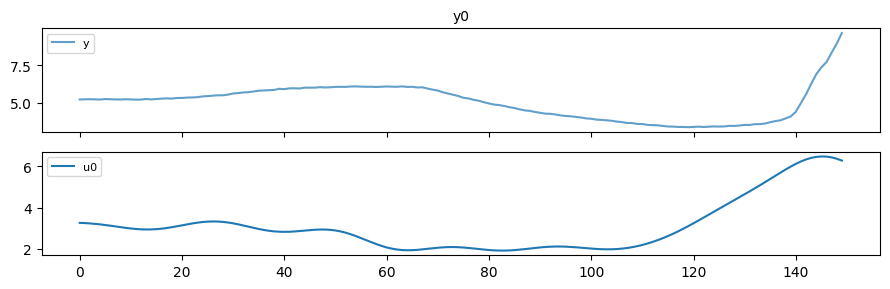

In [3]:
lrn = FranSysLearner(
    dls, init_sz=50, attach_output=True,
    hidden_size=40, metrics=[fun_rmse]
)
lrn.show_batch(max_n=4)

In [4]:
lrn.fit_flat_cos(n_epoch=10, lr=3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  87%|████████▋ | 261/300 [00:00<00:00, 521.49it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 521.49it/s, train=1.0092 | valid=0.4022 | fun_rmse=0.9172]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 544.48it/s, train=1.0092 | valid=0.4022 | fun_rmse=0.9172]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 743.96it/s, train=0.0495 | valid=0.2692 | fun_rmse=0.5888]

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 743.31it/s, train=0.0495 | valid=0.2692 | fun_rmse=0.5888]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 689.39it/s, train=0.0391 | valid=0.2577 | fun_rmse=0.5877]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 688.79it/s, train=0.0391 | valid=0.2577 | fun_rmse=0.5877]

## Visualize Results

Evaluating on the test set. The first 50 timesteps (diagnosis window)
are zero-padded because the model uses that region for state estimation
rather than prediction.

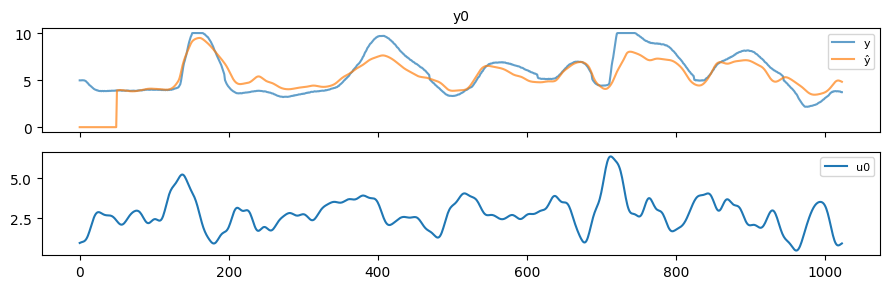

In [5]:
lrn.show_results(dl=lrn.dls.test, max_n=2)

## Adding Activation Regularization

FranSys models benefit significantly from activation regularization, which
encourages smoother predictions. `ActivationRegularizer` penalizes large
activations, `TemporalActivationRegularizer` penalizes abrupt changes between
timesteps. We need to extract the prognosis RNN module from the model so the
regularizers know which layer to hook into.

Pass them as auxiliary losses via `lrn.aux_losses.append(...)`.

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 623.33it/s, train=1.5852 | valid=0.3147 | fun_rmse=0.7101]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 622.87it/s, train=1.5852 | valid=0.3147 | fun_rmse=0.7101]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 300/300 [00:00<00:00, 613.59it/s, train=0.4759 | valid=0.1870 | fun_rmse=0.4711]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 594.75it/s, train=0.1423 | valid=0.1000 | fun_rmse=0.1671]

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 593.47it/s, train=0.1423 | valid=0.1000 | fun_rmse=0.1671]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 649.09it/s, train=0.1239 | valid=0.1053 | fun_rmse=0.1759]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 648.52it/s, train=0.1239 | valid=0.1053 | fun_rmse=0.1759]

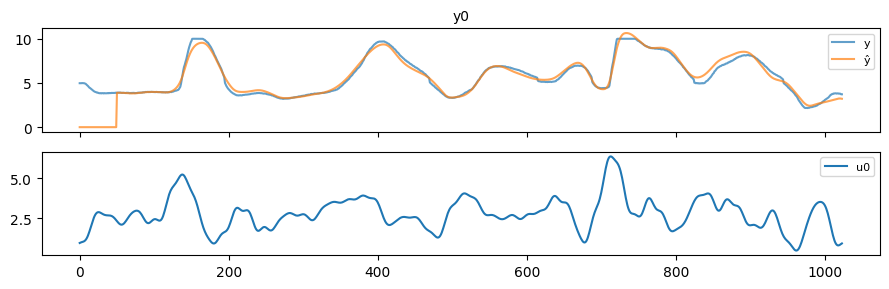

In [6]:
lrn_reg = FranSysLearner(
    dls, init_sz=50, attach_output=True,
    hidden_size=40, metrics=[fun_rmse]
)
model_reg = unwrap_model(lrn_reg.model)
lrn_reg.aux_losses.append(
    ActivationRegularizer(modules=[model_reg.prognosis], alpha=6.0)
)
lrn_reg.aux_losses.append(
    TemporalActivationRegularizer(modules=[model_reg.prognosis], beta=6.0)
)
lrn_reg.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_reg.show_results(dl=lrn_reg.dls.test, max_n=2)

## FranSysRegularizer for State Synchronization

`FranSysRegularizer` adds an auxiliary loss that encourages the prognosis RNN
to maintain state consistency: the hidden state at any point in the prognosis
should be similar to what the diagnosis RNN would produce from the same data
window. This improves long-horizon stability.

The regularizer requires the diagnosis and prognosis modules to be passed
explicitly so it can hook into both and compare their hidden states. The
sync weight `p_state_sync` needs tuning per system -- the library default
(`1e7`) is far too strong for this small model and would let the sync term
dominate the training loss, hurting accuracy.

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  83%|████████▎ | 249/300 [00:00<00:00, 497.26it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 497.26it/s, train=1.8983 | valid=0.3171 | fun_rmse=0.6742]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 501.38it/s, train=1.8983 | valid=0.3171 | fun_rmse=0.6742]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 523.45it/s, train=0.1461 | valid=0.1271 | fun_rmse=0.2230]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  94%|█████████▍| 282/300 [00:00<00:00, 562.63it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 562.63it/s, train=0.1295 | valid=0.1267 | fun_rmse=0.2223]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 561.59it/s, train=0.1295 | valid=0.1267 | fun_rmse=0.2223]

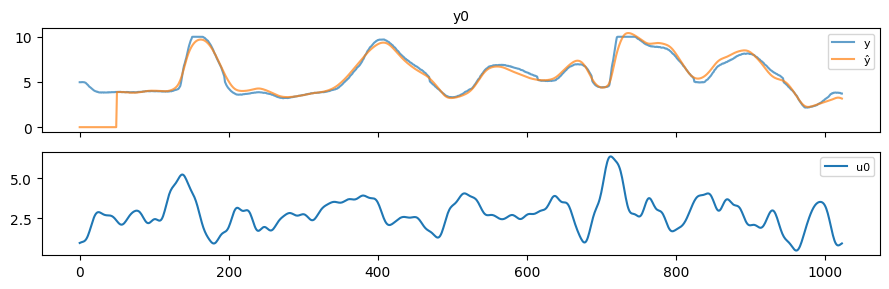

In [7]:
lrn_sync = FranSysLearner(
    dls, init_sz=50, attach_output=True,
    hidden_size=40, metrics=[fun_rmse]
)
model_sync = unwrap_model(lrn_sync.model)
lrn_sync.aux_losses.append(
    ActivationRegularizer(modules=[model_sync.prognosis], alpha=6.0)
)
lrn_sync.aux_losses.append(
    TemporalActivationRegularizer(modules=[model_sync.prognosis], beta=6.0)
)
lrn_sync.aux_losses.append(
    FranSysRegularizer(
        modules=[model_sync.diagnosis, model_sync.prognosis],
        model=model_sync,
        p_state_sync=1e5,
    )
)
lrn_sync.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_sync.show_results(dl=lrn_sync.dls.test, max_n=2)

On this short prognosis horizon the state-synchronized model reaches an
accuracy comparable to the regularizer-only model -- which of the two comes
out ahead varies with the random seed. The sync term's value lies in
stabilizing the hidden-state trajectory over long prognosis horizons, not in
improving short-horizon error.

## Key Takeaways

- FranSys separates state estimation (diagnosis) from forward prediction
  (prognosis).
- `init_sz` controls how many timesteps are used to initialize the hidden
  state from measured data.
- `attach_output=True` enables prediction mode (output feedback).
- `ActivationRegularizer` and `TemporalActivationRegularizer` are especially
  important for FranSys -- they encourage smooth, stable predictions. Pass
  them via `lrn.aux_losses.append(...)`.
- `FranSysRegularizer` adds state synchronization regularization for improved
  long-horizon stability. It requires the diagnosis and prognosis modules
  to be passed so it can compare their hidden states, and its `p_state_sync`
  weight must be tuned per system.
- The architecture naturally handles variable initial conditions.